# Exercise 3 - The Lotka-Volterra model
**Name:** Tristan Mitchell  
**Student Number:** MTCTRI001 


This model is a python translation of the LV_pz model proposed in Glover et al. (2011), Sec. 9.3

You will need to make sure the required modules below are installed in your python environment

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

This is the function containing the right hand side of the ODE system

In [2]:
def LV_pz(x,t,p):
    X1,X2 = x
    p1,p2,p3,p4 = p
    dX1dt = X1 * (p1 - p2*X2)
    dX2dt = X2 * (p3*p2*X1 - p4)
    return np.array([dX1dt,dX2dt])

## Parameters and initial conditions

In [3]:
# The parameters
p = np.array([0.1,0.4,0.2,0.05])
X1_0 = 0.8
X2_0 = 0.171
x0 = np.array([X1_0,X2_0])

## Time axis

In [4]:
# time units are days
Tstart = 0.
Tend = 400.
step = 0.1
t = np.arange(Tstart,Tend,step)

## Integration using the scipy ODE solver

In [5]:
# note that the extra argument containing the parameter "args" must be a tuple
y = odeint(LV_pz, x0, t, args=(p,))

## Plot Fig. 9.3a

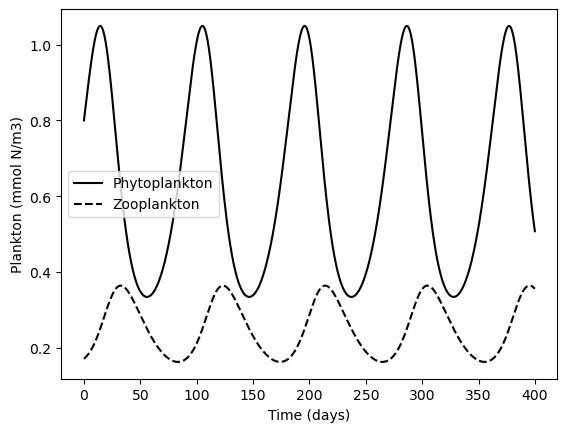

In [6]:
plt.plot(t,y[:,0],'k-',label='Phytoplankton')
plt.plot(t,y[:,1],'k--',label='Zooplankton')
plt.xlabel('Time (days)')
plt.ylabel('Plankton (mmol N/m3)')
plt.legend()
plt.show()

# Exercise 3
1. Write the code to plot Fig. 9.3b, the trajectory in the phase space

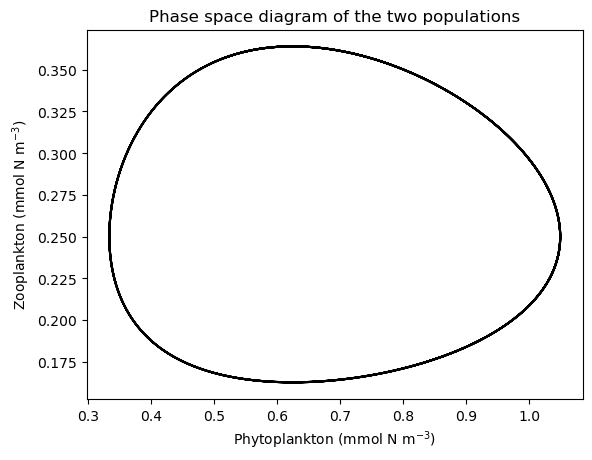

In [7]:
# Plot Fig.9.3b, phase space trajectory (P (state variable x1) plotted vs. the time series of Z (state variable x2)
plt.plot(y[:,0], y[:,1], 'k-') # zooplankton against phytoplankton
plt.xlabel('Phytoplankton (mmol N m$^{-3}$)')
plt.ylabel('Zooplankton (mmol N m$^{-3}$)')
plt.title('Phase space diagram of the two populations')

# Showing the figure
plt.show()

2. Set the parameter p3=1 and compare how different the trajectory is in the phase space

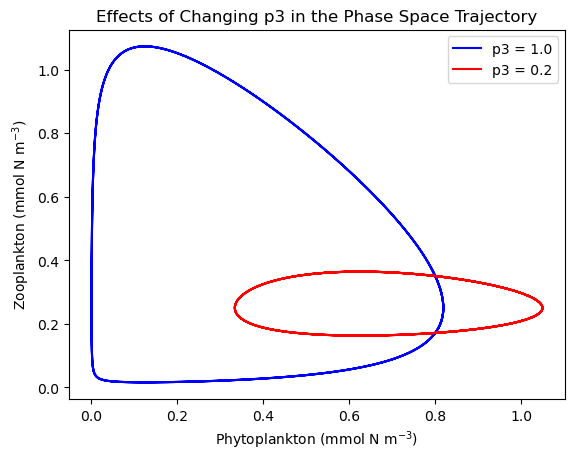

In [11]:
# Create a new parameter array with p3=1 (zooplankton assimilation efficiency)
p_p3changed = np.array([0.1, 0.4, 1.0, 0.05])

# Solve the model again using the new parameter values
y_p3changed = odeint(LV_pz, x0, t, args=(p_p3changed,))

# Plot the phase space trajectories for when p3=1 and p3=0.2
plt.plot(y_p3changed[:,0], y_p3changed[:,1], 'b', label='p3 = 1.0')
plt.plot(y[:,0], y[:,1], 'r', label='p3 = 0.2')

# Add axis labels, title, and a legend
plt.xlabel('Phytoplankton (mmol N m$^{-3}$)')
plt.ylabel('Zooplankton (mmol N m$^{-3}$)')
plt.title('Effects of Changing p3 on the phase space trajectory')
plt.legend()

# Showing the figure
plt.show()

Setting p3 to 1.0 means zooplankton convert all consumed phytoplankton into biomass, whereas at p3 = 0.2, only 20% is converted. As shown in the plot above, this results in a significantly larger phase-space loop. When p3 = 1.0, the zooplankton population increases, placing greater pressure on the phytoplankton. On the other hand, when p3 = 0.2, only a small proportion of the consumed phytoplankton is converted into zooplankton biomass, resulting in a smaller zooplankton population.

3. Write the code to compute the solution of the L-V model using the initial conditions given in the caption of Fig. 9.4

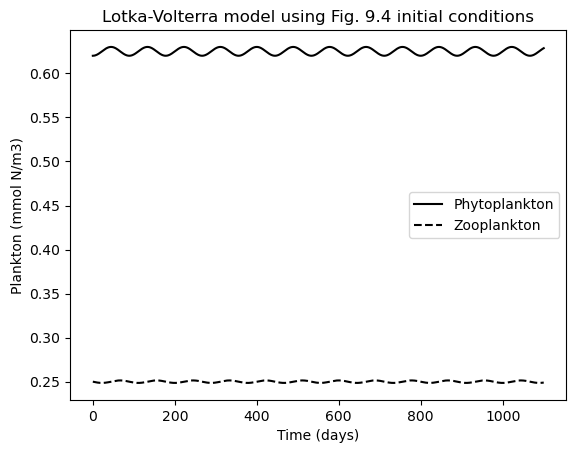

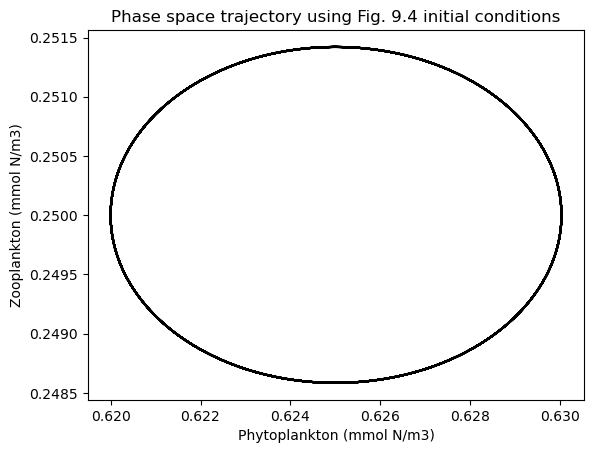

In [9]:
# Fig. 9.4 caption conditions
X1_0_fig94 = 0.62 # initial phytoplankton conc
X2_0_fig94 = 0.25 # initial zooplankton conc
x0_fig94 = np.array([X1_0_fig94, X2_0_fig94])

# Time axis 
# time units are days- Fig.9.4
Tstart_fig94 = 0. # start time 
Tend_fig94 = 1100. # end time 
step_fig94 = 0.1 # time interval
t_fig94 = np.arange(Tstart_fig94, Tend_fig94, step_fig94)

#Integration using the scipy ODE solver (using Fig. 9.4 conditions)
y_fig94 = odeint(LV_pz, x0_fig94, t_fig94, args=(p,)) # note that the extra argument containing the parameter "args" must be a tuple

# Plot Fig.9.4
plt.plot(t_fig94, y_fig94[:,0], 'k-', label='Phytoplankton')
plt.plot(t_fig94, y_fig94[:,1], 'k--', label='Zooplankton')

# Add labels, title, and a legend
plt.xlabel('Time (days)')
plt.ylabel('Plankton (mmol N m$^{-3}$)')
plt.title('Lotka-Volterra time series using Fig. 9.4 Initial Conditions')
plt.legend()

# Showing the figure
plt.show()

# Plot the trajectory in the phase space for Fig.9.4
plt.plot(y_fig94[:,0], y_fig94[:,1], 'k-')

# Adding axis labels and title
plt.xlabel('Phytoplankton (mmol N m$^{-3}$)')
plt.ylabel('Zooplankton (mmol N m$^{-3}$)')
plt.title('Phase Space Trajectory Using Fig. 9.4 Initial Conditions')

# Showing the figure
plt.show()

4. Do you get the same results? Why not? See the errata in the document Glover_etal_2011_ERRATA.pdf to understand more {no need to fully understand the stability analysis ;)}

No, I didn’t get the same result as Fig. 9.4 of Glover et al. This can be explained by slide 64 of the lecture slides, which says, “Since computers can represent numbers only with finite number of digits, there is always a round off error. This is what caused the inconsistency in the numerical solution of the L-V model using MATLAB in Ex. 3.” This is also explained in the Glover et al. 2011 ERRATA.pdf, which notes that the L-V equations are stable and should produce a closed phase-space loop. However, the spiralling pattern we see in Fig. 9.4 is due to small numerical errors that accumulate during the calculations. In other words, when a simulation is run over a long period, that small error can accumulate and slightly change the phase-space trajectory, which is what happened in Fig. 9.4. The Glover et al. 2011 ERRATA.pdf also explains that “What we are actually observing in Fig. 9.4 is an example of an unfavorable interaction between truncation and roundoff error (see Sec. 2.1.5) accumulating in the solution.”